In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780940225.796417 1493800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780940225.971459 1493800 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780940228.287792 1493800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780940231.183941 1493800 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

In [4]:
df_train.head(3)

,tempo,delta,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,14.700000,0,-1.283593,0.39963,-0.15985,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,7.300000,1,-0.582427,0.39963,-0.15985,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,50.299999,0,-0.757718,0.39963,-0.15985,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


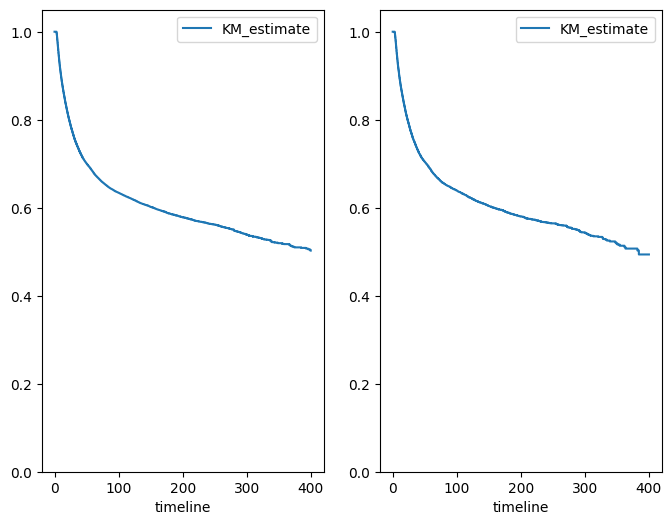

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [6]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Birnbaum-Saunders Model

### Without covariates

In [7]:
def build_bs_model():

    # def softplus_inv(u):
    #     return tf.math.log(tf.math.exp(u) - 1)
        
    parameters = {
        # Birnbaum-Sanders component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        alpha = model.get_variable("alpha")
        beta = model.get_variable("beta")

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        term1 = -tf.math.log( alpha ) - tf.math.log( beta )
        term2 = tf.math.log( sqrt_beta_y + sqrt_beta_y**3 + eps )
        term3 = - 1/(2.0*alpha**2) * (y_safe / beta + beta / y_safe - 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik
        
    return parameters, loglikelihood_loss, None, None, None

In [8]:
with tf.device("/CPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model()
    seed = 10
    bs_model = thf.ModelNN(bs_parameters, bs_loss,
                           bs_neural_network, bs_call,
                           bs_call_nolast, input_dim = (1,), seed = seed)
    bs_model.train_model(epochs = 5000, x = None, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                         early_stopping = True, early_stopping_patience = 10,
                         early_stopping_warmup = 10,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-2, reduce_lr_patience = 5,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 393 / 5000 ]  | Loss:  18336.2109 | Best Loss:  18336.1484 | Speed:  56  epoch/s    | Elapsed Time:  7.01526499  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 10.551 seconds.


I0000 00:00:1780940245.183085 1493800 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x59db0f4452c0


In [9]:
alpha = bs_model.predict("alpha")
beta = bs_model.predict("beta")
print("alpha:", alpha)
print("beta:", beta)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta = tf.math.sqrt(ts_grid / beta)
sqrt_beta_ts = tf.math.sqrt(beta / ts_grid)
z_ts = (1.0 / alpha) * (sqrt_ts_beta - sqrt_beta_ts)

S_ts_train = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()
S_ts_test = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()

sqrt_y_train_beta = tf.math.sqrt(y_train / beta)
sqrt_beta_y_train = tf.math.sqrt(beta / y_train)
z_y_train = (1.0 / alpha) * (sqrt_y_train_beta - sqrt_beta_y_train)
S_train = (0.5 * tf.math.erfc(z_y_train / tf.math.sqrt(2.0))).numpy()

sqrt_y_test_beta = tf.math.sqrt(y_test / beta)
sqrt_beta_y_test = tf.math.sqrt(beta / y_test)
z_y_test = (1.0 / alpha) * (sqrt_y_test_beta - sqrt_beta_y_test)
S_test = (0.5 * tf.math.erfc(z_y_test / tf.math.sqrt(2.0))).numpy()

H_train = -np.log(S_train)
H_test = -np.log(S_test)

alpha: [5.021871]
beta: [40.045555]


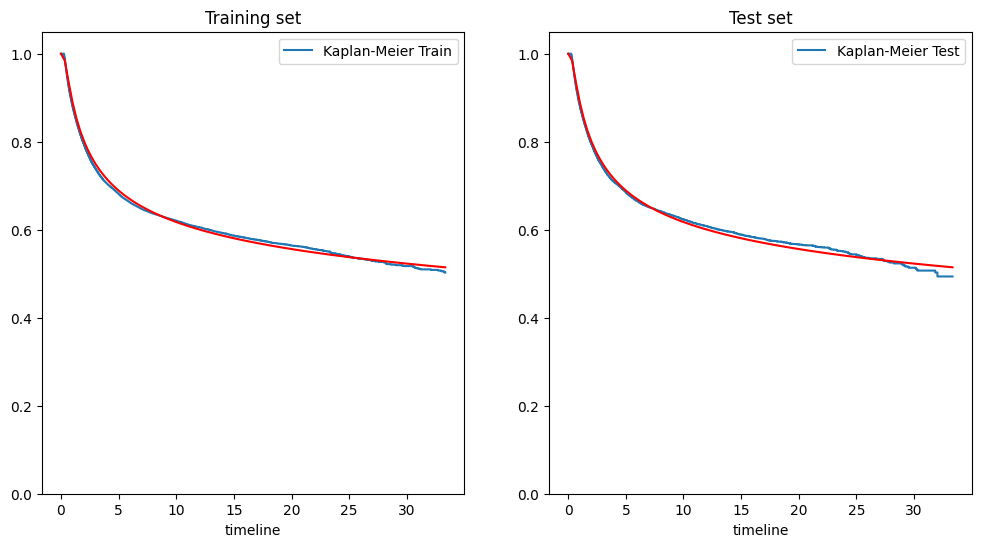

In [10]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With all covariates

In [29]:
def build_bs_model_full( ):    

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    parameters = {
        # Birnbaum-Sanders component
        # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("beta"), "warmup_time": 0},
        # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("beta"), "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)
        beta = model.get_variable("beta", nn_output)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        term1 = -tf.math.log( alpha ) - tf.math.log( beta )
        term2 = tf.math.log(sqrt_beta_y + sqrt_beta_y**3 + eps)
        term3 = - 1/(2.0*alpha**2) * (y_safe / beta + beta / y_safe - 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        # initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        initializer = tf.keras.initializers.HeNormal(seed = seed)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            use_bias = True,
            kernel_initializer = tf.keras.initializers.Zeros()
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [30]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [31]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_full( )
    seed = 10
    bs_model_full = thf.ModelNN(bs_parameters, bs_loss,
                                bs_neural_network, bs_call,
                                bs_call_nolast, input_dim = (X_train.shape[1],), seed = seed)
    bs_model_full.pre_train_model(epochs = 5000, x = X_train, data = data_train,
                                   # optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                   # optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                   # early_stopping = True, reduce_lr_min_delta = 1.0,
                                   shuffle = True, print_freq = 1)
    bs_model_full.train_model(epochs = 5000, x = X_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 10, 
                              early_stopping_warmup = 50,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 2, reduce_lr_patience = 5,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True, finetune_epochs = 5000,
                              finetune_epochs = 1000,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                              finetune_early_stopping_warmup = 50,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1, finetune_reduce_lr_patience = 5,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 293 / 5000 ]  | Loss:  16602.1016 | Best Loss:  16603.6406 | Speed:  30  epoch/s    | Elapsed Time:  9.72433281  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 4999 / 5000 ]  | Loss:  62987.7695 | Best Loss:  62987.7695 | Speed:  47  epoch/s    | Elapsed Time:  105.494263  s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 118.344 seconds.


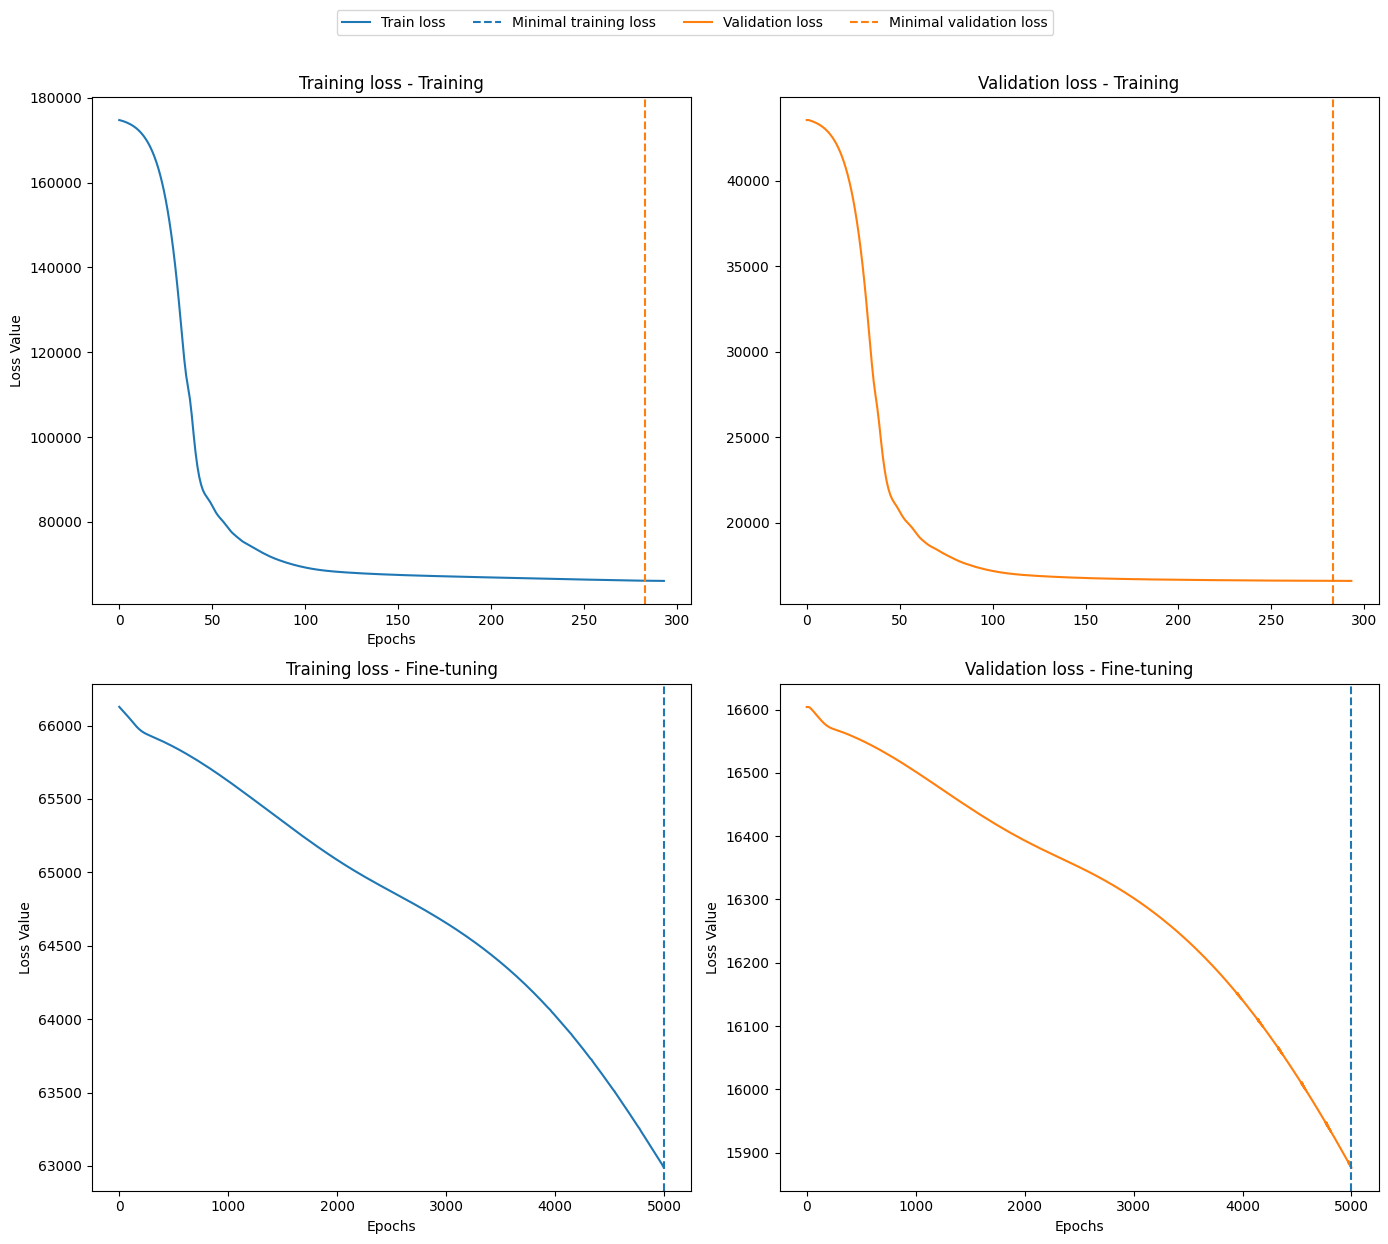

In [32]:
utils.plot_model_convergence( bs_model_full )

In [34]:
pars_train = bs_model_full.predict(X_train)
pars_test = bs_model_full.predict(X_test)

# alpha_train = bs_model_full.predict("alpha")
# alpha_test = bs_model_full.predict("alpha")
alpha_train = pars_train["alpha"].numpy().flatten()
alpha_test = pars_test["alpha"].numpy().flatten()
beta_train = pars_train["beta"].numpy().flatten()
beta_test = pars_test["beta"].numpy().flatten()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_train_full = tf.math.sqrt(ts_grid / beta_train)
sqrt_beta_ts_train_full = tf.math.sqrt(beta_train / ts_grid)
z_ts_train_full = (1.0 / alpha_train) * (sqrt_ts_beta_train_full - sqrt_beta_ts_train_full)
S_ts_train_full = (0.5 * tf.math.erfc(z_ts_train_full / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_test_full = tf.math.sqrt(ts_grid / beta_test)
sqrt_beta_ts_test_full = tf.math.sqrt(beta_test / ts_grid)
z_ts_test_full = (1.0 / alpha_test) * (sqrt_ts_beta_test_full - sqrt_beta_ts_test_full)
S_ts_test_full = (0.5 * tf.math.erfc(z_ts_test_full / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_train_full = np.sqrt(y_train / beta_train)
sqrt_beta_y_train_full = np.sqrt(beta_train / y_train)
z_y_train_full = (1.0 / alpha_train) * (sqrt_y_beta_train_full - sqrt_beta_y_train_full)
S_train_full = (0.5 * tf.math.erfc(z_y_train_full / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_test_full = np.sqrt(y_test / beta_test)
sqrt_beta_y_test_full = np.sqrt(beta_test / y_test)
z_y_test_full = (1.0 / alpha_test) * (sqrt_y_beta_test_full - sqrt_beta_y_test_full)
S_test_full = (0.5 * tf.math.erfc(z_y_test_full / tf.math.sqrt(2.0))).numpy()

H_train_full = -np.log( S_train_full )
H_test_full = -np.log( S_test_full )

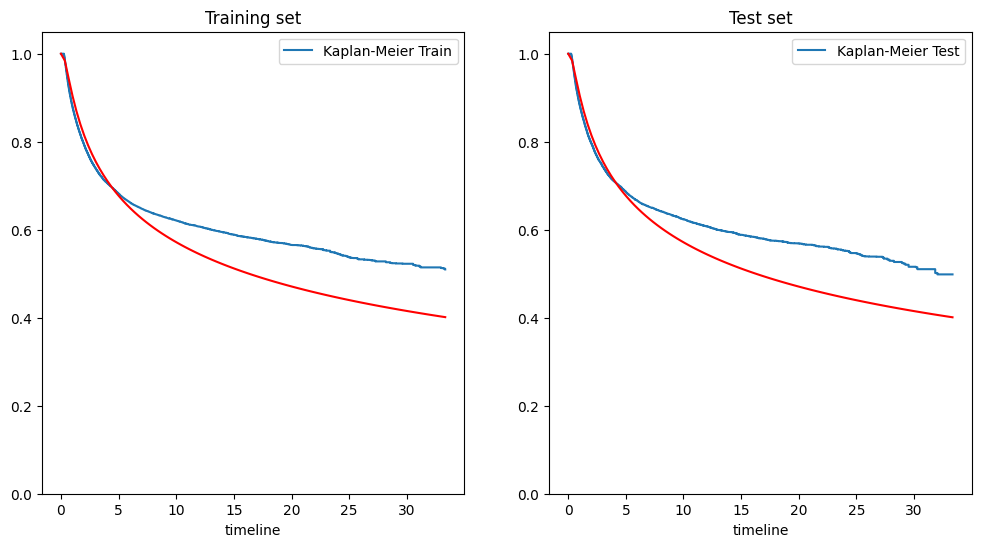

In [35]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 1000
n_max = S_ts_train_full.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_full.shape[1]), size = n_max )
test_idx = np.random.choice( np.arange(S_ts_test_full.shape[1]), size = n_max )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_full[:, train_idx], S_ts_test_full[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

### Fully Linear model

In [176]:
z_train.shape

(225000, 11)

In [177]:
W_train_nn.shape

(11, 86)

In [179]:
np.dot(z_train, W_train_nn).shape

(225000, 86)

In [185]:
def cross_correlation(X, Z):
    combined_df = pd.concat([X, Z], axis = 1)
    full_corr = combined_df.corr()
    Z_cols = Z.columns
    X_cols = X.columns
    cross_corr = full_corr.loc[Z_cols, X_cols]
    return cross_corr

In [197]:
# Cross correlation between Z and X removing the intercept column
cross_corr_z_X_nn_train = cross_correlation(z_train, X_train_nn).iloc[:,1:]
cross_corr_z_X_nn_train.head()

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
horas_semanais,1.694358e-16,2.032474e-18,-2.672667e-19,-1.469085e-17,1.692082e-17,2.569785e-17,7.325099e-17,-9.750355e-18,5.198398e-18,-6.259335e-17
qtd_dias_afastamento,-8.833128e-17,-5.393597e-17,-1.021148e-17,-3.806522e-18,4.276946e-18,-2.971916e-17,-4.232250e-17,1.984323e-17,2.980285e-17,-6.553118e-18
escolaridade_5 ano completo,-2.080942e-16,-3.414502e-17,-1.464532e-17,-3.914499e-18,-7.551365e-18,-3.417183e-17,-2.542182e-17,-1.382863e-17,-1.521970e-17,-6.413522e-18
escolaridade_6 a 9 ano incompleto,-3.880812e-16,-1.167250e-17,2.159512e-17,6.475945e-18,2.654579e-17,-1.044473e-16,-6.989408e-17,1.199809e-17,2.190774e-17,-9.261299e-17
escolaridade_analfabeto,-4.911970e-17,-3.068790e-17,-2.348772e-17,-5.032067e-17,-1.208377e-19,-2.744391e-17,-3.440726e-18,-7.191499e-19,-1.930122e-17,-1.293708e-17


In [201]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns]
z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
z_proj_X_test = np.dot(z_test, W_test_nn)
X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,intercept,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,1.0,-1.283593,0,0,0,1,0,0,0,0,0
1,1.0,-0.582427,0,0,0,0,0,0,0,0,0
2,1.0,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.083176,-0.069047,-0.004282,-0.019212,-0.001159,-0.006684,0.001802,-0.039803,-0.061752,0.001922,...,-0.073988,-0.006774,-0.019128,-0.256823,-0.033569,0.964214,-0.218982,-0.093015,-0.000856,-0.001773
1,0.227910,-0.087339,-0.009463,-0.028348,-0.002376,-0.010841,-0.000394,-0.065626,-0.060406,-0.001251,...,-0.067658,-0.006806,-0.028568,-0.240060,-0.030286,-0.046825,-0.214215,-0.091127,-0.001132,-0.003240
2,0.418252,-0.114017,-0.003280,-0.008485,0.000037,-0.002057,-0.001857,-0.028287,-0.033659,-0.005547,...,-0.096551,-0.002773,-0.081718,-0.217377,-0.039068,0.766384,-0.149224,-0.185876,-0.000772,-0.008217


In [202]:
def build_bs_model_linear_effects( ):    

    initial_intercept = np.log(np.median(y_train))
    init_vector = np.zeros(z_train.shape[1])
    init_vector[0] = initial_intercept # Set ONLY the intercept to the median
    
    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    parameters = {
        # Birnbaum-Sanders component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "beta_beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": z_train.shape[1], "init": init_vector, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, z_beta, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)

        beta_beta = model.get_variable("beta_beta")[:,None]
        
        # beta = model.get_variable("beta", nn_output)
        beta = tf.math.exp( tf.matmul(z_beta, beta_beta) )

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        term1 = -tf.math.log( alpha ) - tf.math.log( beta )
        term2 = tf.math.log(sqrt_beta_y + sqrt_beta_y**3 + eps)
        term3 = - 1/(2.0*alpha**2) * (y_safe / beta + beta / y_safe - 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        # initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        initializer = tf.keras.initializers.HeNormal(seed = seed)

        model.dense1 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense2 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.output_layer = layers.Dense(
            units = 1,
            activation = None,
            use_bias = True,
            kernel_initializer = tf.keras.initializers.Zeros()
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [203]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_linear_effects( )
    seed = 10
    bs_model_full_linear = thf.ModelNN(bs_parameters, bs_loss,
                                       bs_neural_network, bs_call,
                                       bs_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model_full_linear.pre_train_model(epochs = 1000, x = X_train_nn, data = data_train, shuffle = True, print_freq = 1)
    bs_model_full_linear.train_model(epochs = 1000, x = X_train_nn, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                     fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                     early_stopping = True, early_stopping_patience = 10,
                                     early_stopping_warmup = 50,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 2, reduce_lr_patience = 5,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     fine_tune = True, 
                                     finetune_epochs = 1000,
                                     finetune_reduce_lr_min_delta = 1,
                                     deterministic = True,
                                     verbose = True, print_freq = 1,
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 172 / 1000 ]  | Loss:  16429.6777 | Best Loss:  16412.5273 | Speed:  50  epoch/s    | Elapsed Time:  3.41353512  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 349 / 1000 ]  | Loss:  61403.8086 | Best Loss:  61404.707 | Speed:  69  epoch/s    | Elapsed Time:  5.04871559  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 11.372 seconds.


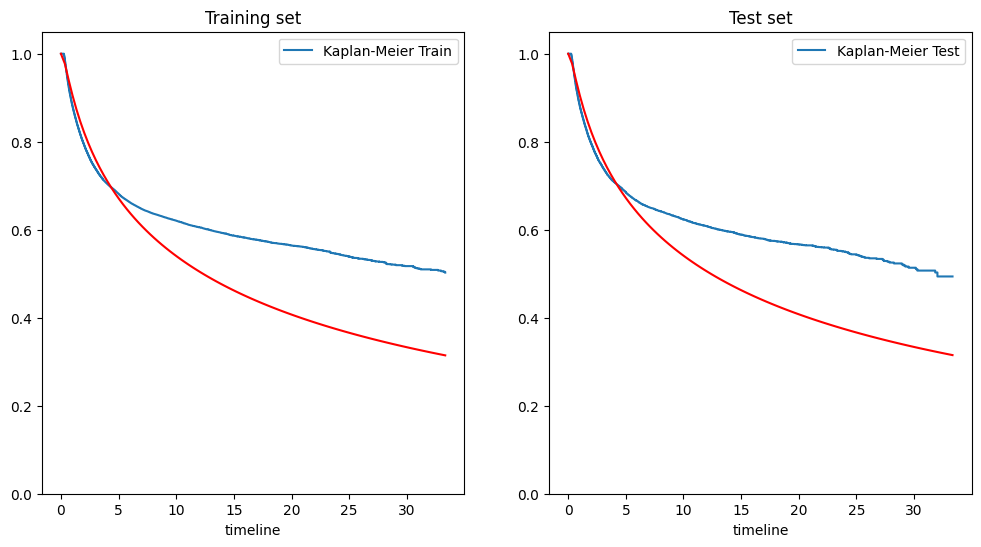

In [265]:
alpha_train = bs_model_full_linear.predict(X_train_nn)["alpha"].numpy().flatten()
alpha_test = bs_model_full_linear.predict(X_test_nn)["alpha"].numpy().flatten()

beta_beta_train = bs_model_full_linear.predict( "beta_beta" )[:,None]
beta_beta_test = bs_model_full_linear.predict( "beta_beta" )[:,None]

z_train_tf = tf.cast(z_train, tf.float32)
z_test_tf = tf.cast(z_test, tf.float32)

beta_train = tf.math.exp( np.dot(z_train_tf, beta_beta_train).flatten() ).numpy()
beta_test = tf.math.exp( np.dot(z_test_tf, beta_beta_test).flatten() ).numpy()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_train_linear = tf.math.sqrt(ts_grid / beta_train)
sqrt_beta_ts_train_linear = tf.math.sqrt(beta_train / ts_grid)
z_ts_train_linear = (1.0 / alpha_train) * (sqrt_ts_beta_train_linear - sqrt_beta_ts_train_linear)
S_ts_train_linear = (0.5 * tf.math.erfc(z_ts_train_linear / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_test_linear = tf.math.sqrt(ts_grid / beta_test)
sqrt_beta_ts_test_linear = tf.math.sqrt(beta_test / ts_grid)
z_ts_test_linear = (1.0 / alpha_test) * (sqrt_ts_beta_test_linear - sqrt_beta_ts_test_linear)
S_ts_test_linear = (0.5 * tf.math.erfc(z_ts_test_linear / tf.math.sqrt(2.0))).numpy()

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
# n_max = 1000
n_max = S_ts_train_linear.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_linear.shape[1]), size = np.min([n_max, S_ts_train_linear.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_linear.shape[1]), size = np.min([n_max, S_ts_test_linear.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_linear[:, train_idx], S_ts_test_linear[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

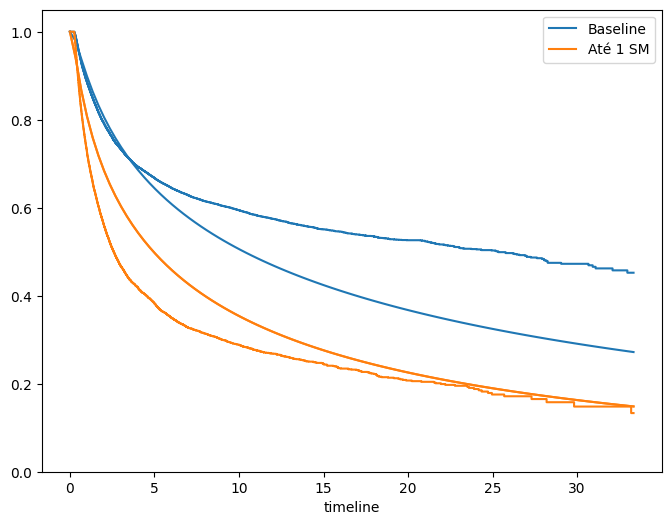

In [266]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Baseline
mask_baseline = (z_train.iloc[:, [7,8,9,10]] == 0).all(axis = 1)

X_baseline_nn = X_train_nn.loc[mask_baseline, :]
z_baseline_linear = z_train.loc[mask_baseline, :]
z_baseline_linear_tf = tf.cast(z_baseline_linear, tf.float32)

alpha_baseline = bs_model_full_linear.predict(X_baseline_nn)["alpha"].numpy().flatten()
beta_beta_baseline = bs_model_full_linear.predict( "beta_beta" )[:,None]
beta_baseline = tf.math.exp( np.dot(z_baseline_linear_tf, beta_beta_baseline).flatten() ).numpy()

# Até 1 SM
mask_ate1sm = z_train["faixa_remuneracao_media_até 1 SM"] == 1
# mask_ate1sm = (z_train["faixa_remuneracao_media_até 1 SM"] == 1) | (z_train["faixa_remuneracao_media_até 1 SM"] == 0)
X_ate1sm = X_train_nn.loc[mask_ate1sm, :]
z_ate1sm_linear = z_train.loc[mask_ate1sm, :]
z_ate1sm_linear_tf = tf.cast(z_ate1sm_linear, tf.float32)

alpha_ate1sm = bs_model_full_linear.predict(X_ate1sm)["alpha"].numpy().flatten()
beta_beta_ate1sm = bs_model_full_linear.predict( "beta_beta" )[:,None]
beta_ate1sm = tf.math.exp( np.dot(z_ate1sm_linear_tf, beta_beta_ate1sm).flatten() ).numpy()

# Survival curves
ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_baseline_linear = tf.math.sqrt(ts_grid / beta_baseline)
sqrt_beta_ts_baseline_linear = tf.math.sqrt(beta_baseline / ts_grid)
z_ts_baseline = (1.0 / alpha_baseline) * (sqrt_ts_beta_baseline_linear - sqrt_beta_ts_baseline_linear)
S_ts_baseline = (0.5 * tf.math.erfc(z_ts_baseline / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_ate1sm_linear = tf.math.sqrt(ts_grid / beta_ate1sm)
sqrt_beta_ts_ate1sm_linear = tf.math.sqrt(beta_ate1sm / ts_grid)
z_ts_ate1sm = (1.0 / alpha_ate1sm) * (sqrt_ts_beta_ate1sm_linear - sqrt_beta_ts_ate1sm_linear)
S_ts_ate1sm = (0.5 * tf.math.erfc(z_ts_ate1sm / tf.math.sqrt(2.0))).numpy()

# Plotting the survival curves
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# for i in range(10):
#     ax.plot(ts_grid.flatten(), S_ts_baseline[:, i], color = colors[0], alpha = 0.2)
#     ax.plot(ts_grid.flatten(), S_ts_ate1sm[:, i], color = colors[1], alpha = 0.2)

ax.plot(ts_grid.flatten(), np.mean( S_ts_ate1sm, axis = 1 ), color = colors[1])

ax.plot(ts_grid.flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

ax.plot(ts_grid.flatten(), np.mean( S_ts_ate1sm, axis = 1 ), color = colors[1])

km = lifelines.KaplanMeierFitter()
km.fit(df_baseline["tempo"] / 12, df_baseline["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = colors[0])
ax.set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_ate1sm["tempo"] / 12, df_ate1sm["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = colors[1])
ax.set_ylim(0,1.05)

plt.show()

<Axes: ylabel='Count'>

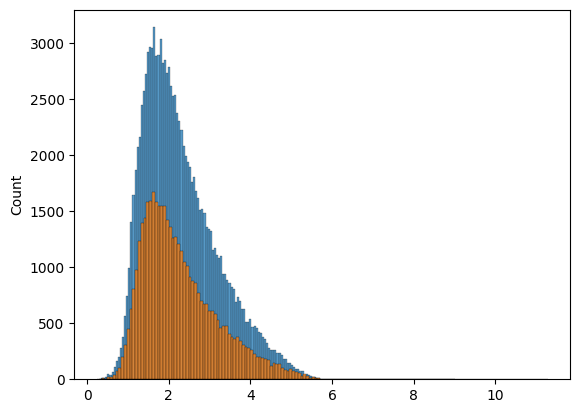

In [263]:
sns.histplot(alpha_baseline)
sns.histplot(alpha_ate1sm)

### With mixed covariates

In [264]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]

z_test = X_test.iloc[:, linear_columns]
z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,intercept,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,1.0,-1.283593,0,0,0,1,0,0,0,0,0
1,1.0,-0.582427,0,0,0,0,0,0,0,0,0
2,1.0,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [90]:
def build_bs_model_linear_effects( ):    

    initial_intercept = np.log(np.median(y_train))
    init_vector = np.zeros(z_train.shape[1])
    init_vector[0] = initial_intercept # Set ONLY the intercept to the median
    
    parameters = {
        # Birnbaum-Sanders component
        "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 10000},
        "beta_beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": z_train.shape[1], "init": init_vector, "warmup_time": 0},
        "beta_nn": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 0.1, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, z_beta, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)

        beta_beta = model.get_variable("beta_beta")[:,None]
        beta_nn = model.get_variable("beta_nn", nn_output)
        
        # beta = model.get_variable("beta", nn_output)
        beta = tf.math.exp( tf.matmul(z_beta, beta_beta) + beta_nn )

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        term1 = -tf.math.log( alpha ) - tf.math.log( beta )
        term2 = tf.math.log(sqrt_beta_y + sqrt_beta_y**3 + eps)
        term3 = - 1/(2.0*alpha**2) * (y_safe / beta + beta / y_safe - 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        # initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        initializer = tf.keras.initializers.HeNormal(seed = seed)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            use_bias = True,
            kernel_initializer = tf.keras.initializers.Zeros()
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    # return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast
    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [129]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_linear_effects( )
    seed = 10
    bs_model_linear = thf.ModelNN(bs_parameters, bs_loss,
                                  bs_neural_network, bs_call,
                                  bs_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model_linear.pre_train_model(epochs = None, x = X_train_nn, data = data_train,
                                    optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                    optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                    early_stopping = True, reduce_lr_min_delta = 1.0,
                                    shuffle = True, print_freq = 1)
    bs_model_linear.train_model(epochs = 1000, x = X_train_nn, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 5.0),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 5.0),
                                fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                early_stopping = True, early_stopping_patience = 10,
                                early_stopping_warmup = 50,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 2, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True, finetune_epochs = 5000,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                finetune_early_stopping_warmup = 50,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1, finetune_reduce_lr_patience = 5,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 328 / 1000 ]  | Loss:  16655.4414 | Best Loss:  16645.6094 | Speed:  27  epoch/s    | Elapsed Time:  11.8698559  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1456 / 5000 ]  | Loss:  62032.1094 | Best Loss:  62032.9688 | Speed:  44  epoch/s    | Elapsed Time:  32.540123  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 48.144 seconds.


/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2601: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(
W0000 00:00:1780942511.507974 1493800 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


In [131]:
bs_model_linear.get_covariances(jitter = 1.0e-2)

In [132]:
pars_train = bs_model_linear.predict(X_train_nn)
pars_test = bs_model_linear.predict(X_test_nn)

# alpha_train = bs_model_linear.predict("alpha")
# alpha_test = bs_model_linear.predict("alpha")
alpha_train = pars_train["alpha"].numpy().flatten()
alpha_test = pars_test["alpha"].numpy().flatten()

beta_beta_train = bs_model_linear.predict( "beta_beta" )[:,None]
beta_beta_test = bs_model_linear.predict( "beta_beta" )[:,None]
beta_nn_train = pars_train["beta_nn"].numpy().flatten()
beta_nn_test = pars_test["beta_nn"].numpy().flatten()

z_train_tf = tf.cast(z_train, tf.float32)
z_test_tf = tf.cast(z_test, tf.float32)

beta_train = tf.math.exp( np.dot(z_train_tf, beta_beta_train).flatten() + beta_nn_train ).numpy()
beta_test = tf.math.exp( np.dot(z_test_tf, beta_beta_test).flatten() + beta_nn_test ).numpy()

# beta_train = tf.math.softplus( beta_nn_train + np.dot(z_train, beta_beta_train).flatten() ).numpy()
# beta_test = tf.math.softplus( beta_nn_test + np.dot(z_test, beta_beta_test).flatten() ).numpy()
# beta_train = tf.math.exp( np.dot(z_train, beta_beta_train).flatten() ).numpy() + beta_nn_train
# beta_test = tf.math.exp( np.dot(z_test, beta_beta_test).flatten() ).numpy() + beta_nn_test

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_train_linear = tf.math.sqrt(ts_grid / beta_train)
sqrt_beta_ts_train_linear = tf.math.sqrt(beta_train / ts_grid)
z_ts_train_linear = (1.0 / alpha_train) * (sqrt_ts_beta_train_linear - sqrt_beta_ts_train_linear)
S_ts_train_linear = (0.5 * tf.math.erfc(z_ts_train_linear / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_test_linear = tf.math.sqrt(ts_grid / beta_test)
sqrt_beta_ts_test_linear = tf.math.sqrt(beta_test / ts_grid)
z_ts_test_linear = (1.0 / alpha_test) * (sqrt_ts_beta_test_linear - sqrt_beta_ts_test_linear)
S_ts_test_linear = (0.5 * tf.math.erfc(z_ts_test_linear / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_train_linear = np.sqrt(y_train / beta_train)
sqrt_beta_y_train_linear = np.sqrt(beta_train / y_train)
z_y_train_linear = (1.0 / alpha_train) * (sqrt_y_beta_train_linear - sqrt_beta_y_train_linear)
S_train_linear = (0.5 * tf.math.erfc(z_y_train_linear / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_test_linear = np.sqrt(y_test / beta_test)
sqrt_beta_y_test_linear = np.sqrt(beta_test / y_test)
z_y_test_linear = (1.0 / alpha_test) * (sqrt_y_beta_test_linear - sqrt_beta_y_test_linear)
S_test_linear = (0.5 * tf.math.erfc(z_y_test_linear / tf.math.sqrt(2.0))).numpy()

H_train_linear = -np.log( S_train_linear )
H_test_linear = -np.log( S_test_linear )

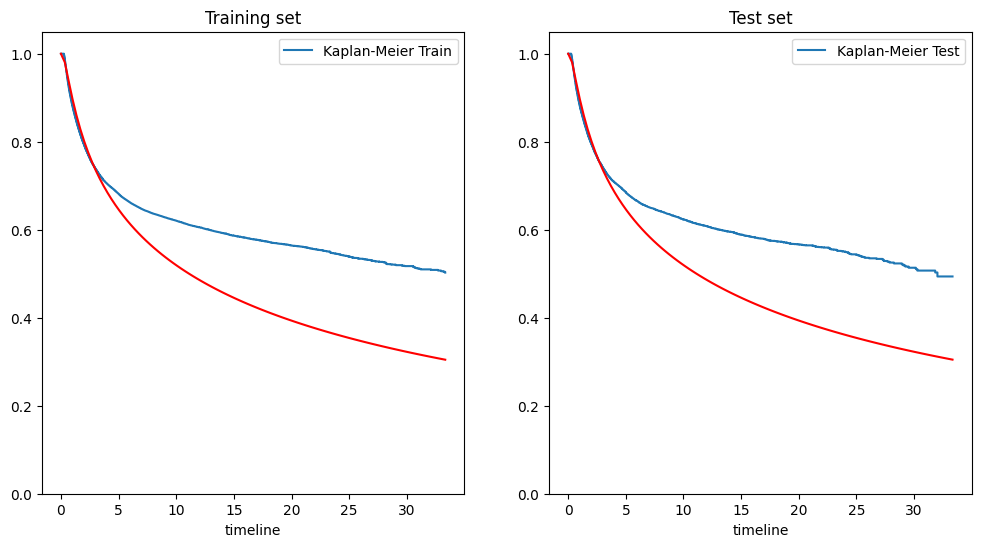

In [133]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
# n_max = 2000
n_max = S_ts_train_linear.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_linear.shape[1]), size = np.min([n_max, S_ts_train_linear.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_linear.shape[1]), size = np.min([n_max, S_ts_test_linear.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_linear[:, train_idx], S_ts_test_linear[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [134]:
beta_summary = bs_model_linear.summary()
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,index,beta_beta[0],beta_beta[0]_se,beta_beta[0]_lower,beta_beta[0]_upper,beta_beta[1],beta_beta[1]_se,beta_beta[1]_lower,beta_beta[1]_upper,beta_beta[2],...,beta_beta[8]_lower,beta_beta[8]_upper,beta_beta[9],beta_beta[9]_se,beta_beta[9]_lower,beta_beta[9]_upper,beta_beta[10],beta_beta[10]_se,beta_beta[10]_lower,beta_beta[10]_upper
0,1,-0.138589,6.532617,-12.942284,12.665106,0.288326,0.004568,0.279374,0.297278,0.036714,...,0.592678,0.669439,-0.687684,0.011859,-0.710927,-0.664441,0.865852,0.022515,0.821724,0.90998


In [135]:
beta_summary = bs_model_linear.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
intercept,-0.138589,6.532617,-0.021215,0.983074,(-12.9423 ; 12.6651)
idade,0.288326,0.004568,63.124662,0.000000,(0.2794 ; 0.2973)
sexo_feminino,0.036714,0.009219,3.982312,0.000068,(0.0186 ; 0.0548)
raca_amarela,-0.048943,0.040742,-1.201284,0.229641,(-0.1288 ; 0.0309)
raca_indigena,-0.192231,0.083906,-2.291025,0.021962,(-0.3567 ; -0.0278)
raca_parda,-0.012059,0.009593,-1.257092,0.208720,(-0.0309 ; 0.0067)
raca_preta,-0.057078,0.016605,-3.437399,0.000587,(-0.0896 ; -0.0245)
faixa_remuneracao_media_2 a 4 SM,0.452377,0.011945,37.871981,0.000000,(0.429 ; 0.4758)
faixa_remuneracao_media_4 a 7 SM,0.631058,0.019582,32.226101,0.000000,(0.5927 ; 0.6694)
faixa_remuneracao_media_até 1 SM,-0.687684,0.011859,-57.988622,0.000000,(-0.7109 ; -0.6644)


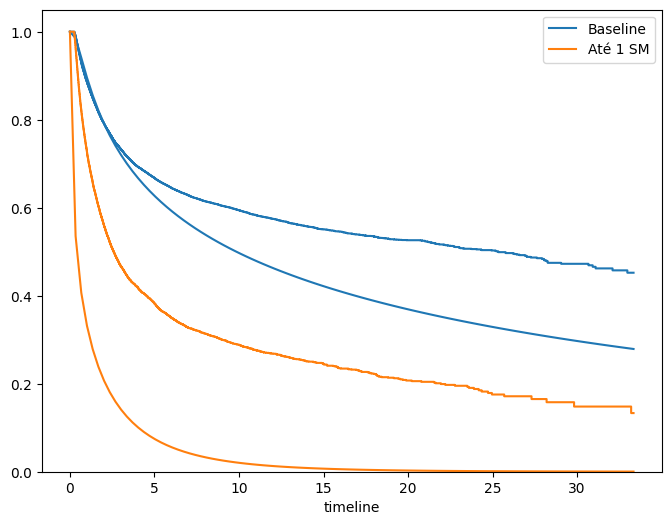

In [137]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Baseline
df_baseline = df_train.loc[ (df_train.iloc[:, [10,11,12,13]] == 0).all(axis = 1), : ]
X_baseline = df_baseline.iloc[:, 2:]
z_baseline_linear = X_baseline.iloc[:, linear_columns]
z_baseline_linear.insert(0, "intercept", 1.0)
z_baseline_linear_tf = tf.cast(z_baseline_linear, tf.float32)

X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]

pars_baseline = bs_model_linear.predict(X_baseline_nn)

# alpha_baseline = bs_model_linear.predict("alpha")
alpha_baseline = pars_baseline["alpha"].numpy().flatten()

beta_beta_baseline = bs_model_linear.predict( "beta_beta" )[:,None]
beta_nn_baseline = bs_model_linear.predict(X_baseline_nn)["beta_nn"].numpy().flatten()

# beta_baseline = tf.math.softplus( beta_nn_baseline + np.dot(z_baseline_linear, beta_beta_baseline).flatten() ).numpy()
beta_baseline = tf.math.exp( np.dot(z_baseline_linear, beta_beta_baseline).flatten() + beta_nn_baseline ).numpy()
# beta_baseline = tf.math.exp( np.dot(z_baseline_linear_tf, beta_beta_baseline).flatten() ).numpy()

ts_grid = tf.cast( np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None], tf.float32 )

sqrt_ts_beta_baseline_linear = tf.math.sqrt(ts_grid / beta_baseline)
sqrt_beta_ts_baseline_linear = tf.math.sqrt(beta_baseline / ts_grid)
z_ts_baseline = (1.0 / alpha_baseline) * (sqrt_ts_beta_baseline_linear - sqrt_beta_ts_baseline_linear)
S_ts_baseline = (0.5 * tf.math.erfc(z_ts_baseline / tf.math.sqrt(2.0))).numpy()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

df_ate1sm = df_train.loc[ df_train["faixa_remuneracao_media_até 1 SM"] == 1, : ]
X_ate1sm = df_ate1sm.iloc[:, 2:]
z_ate1sm_linear = X_ate1sm.iloc[:, linear_columns]
z_ate1sm_linear.insert(0, "intercept", 1.0)
z_ate1sm_linear_tf = tf.cast(z_ate1sm_linear, tf.float32)
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

pars_ate1sm = bs_model_linear.predict(X_ate1sm_nn)

# alpha_ate1sm = bs_model_linear.predict("alpha")
alpha_ate1sm = pars_ate1sm["alpha"].numpy().flatten()

beta_beta_ate1sm = bs_model_linear.predict( "beta_beta" )[:,None]
# beta_nn_ate1sm = pars_ate1sm["beta_nn"].numpy().flatten()

# beta_ate1sm = tf.math.softplus( beta_nn_ate1sm + np.dot(z_ate1sm_linear, beta_beta_ate1sm).flatten() ).numpy()
beta_ate1sm = tf.math.exp( np.dot(z_ate1sm_linear_tf, beta_beta_ate1sm).flatten() ).numpy()

sqrt_ts_beta_ate1sm_linear = tf.math.sqrt(ts_grid / beta_ate1sm)
sqrt_beta_ts_ate1sm_linear = tf.math.sqrt(beta_ate1sm / ts_grid)
z_ts_ate1sm = (1.0 / alpha_ate1sm) * (sqrt_ts_beta_ate1sm_linear - sqrt_beta_ts_ate1sm_linear)
S_ts_ate1sm = (0.5 * tf.math.erfc(z_ts_ate1sm / tf.math.sqrt(2.0))).numpy()

ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_ate1sm, axis = 1 ), color = colors[1])

km = lifelines.KaplanMeierFitter()
km.fit(df_baseline["tempo"] / 12, df_baseline["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = colors[0])
ax.set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_ate1sm["tempo"] / 12, df_ate1sm["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = colors[1])
ax.set_ylim(0,1.05)

plt.show()

# Model evaluation

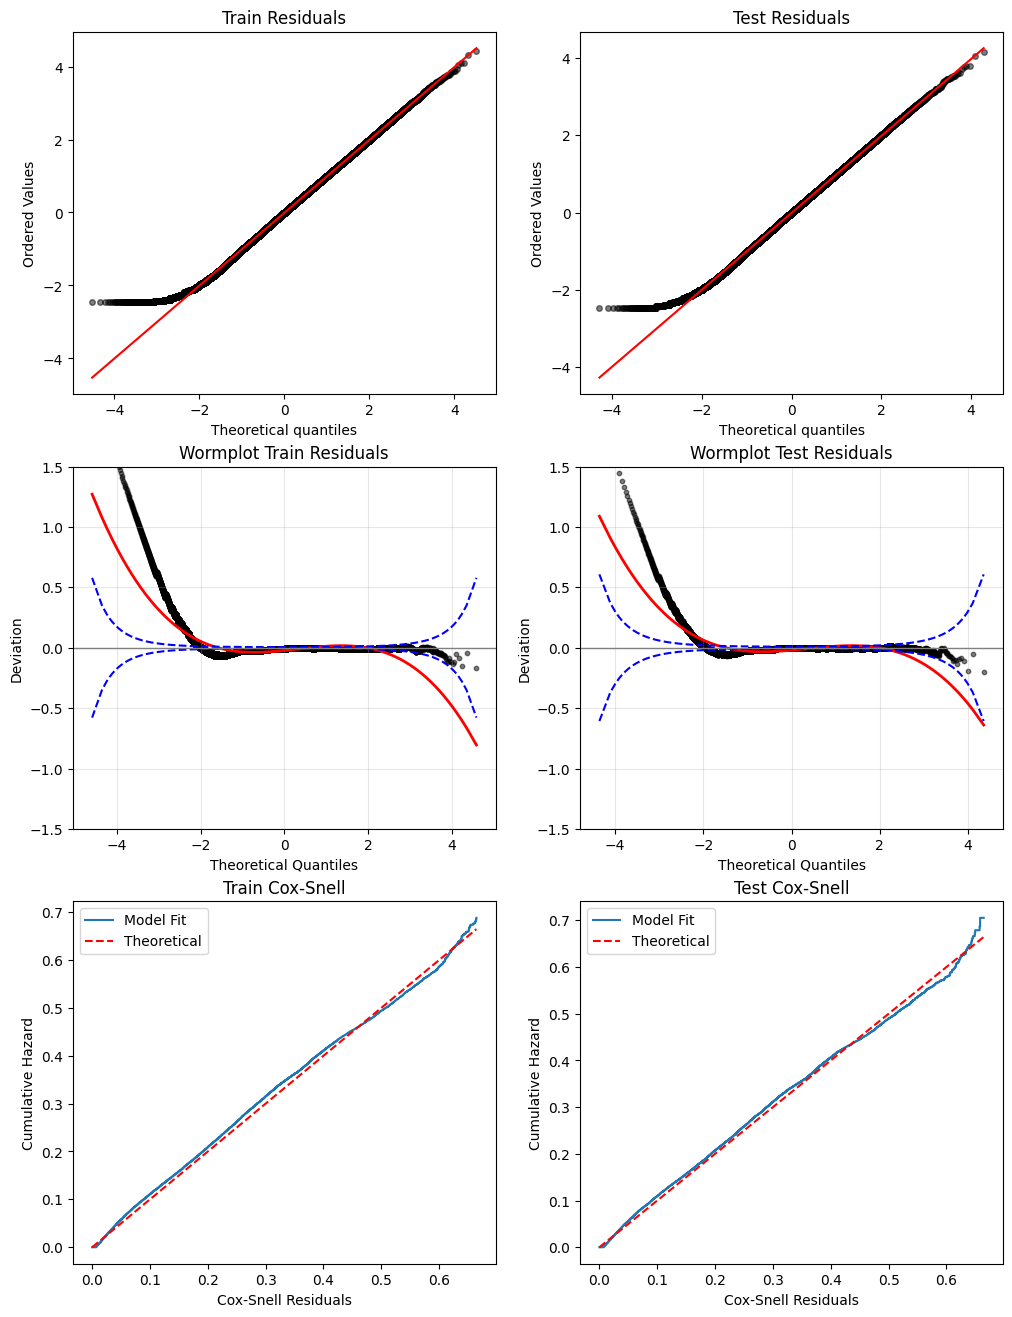

In [138]:
quant_residuals_train = utils.compute_randomized_residuals_censoring(S_train, delta_train)
quant_residuals_test = utils.compute_randomized_residuals_censoring(S_test, delta_test)
cs_residuals_train = H_train
cs_residuals_test = H_test 

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

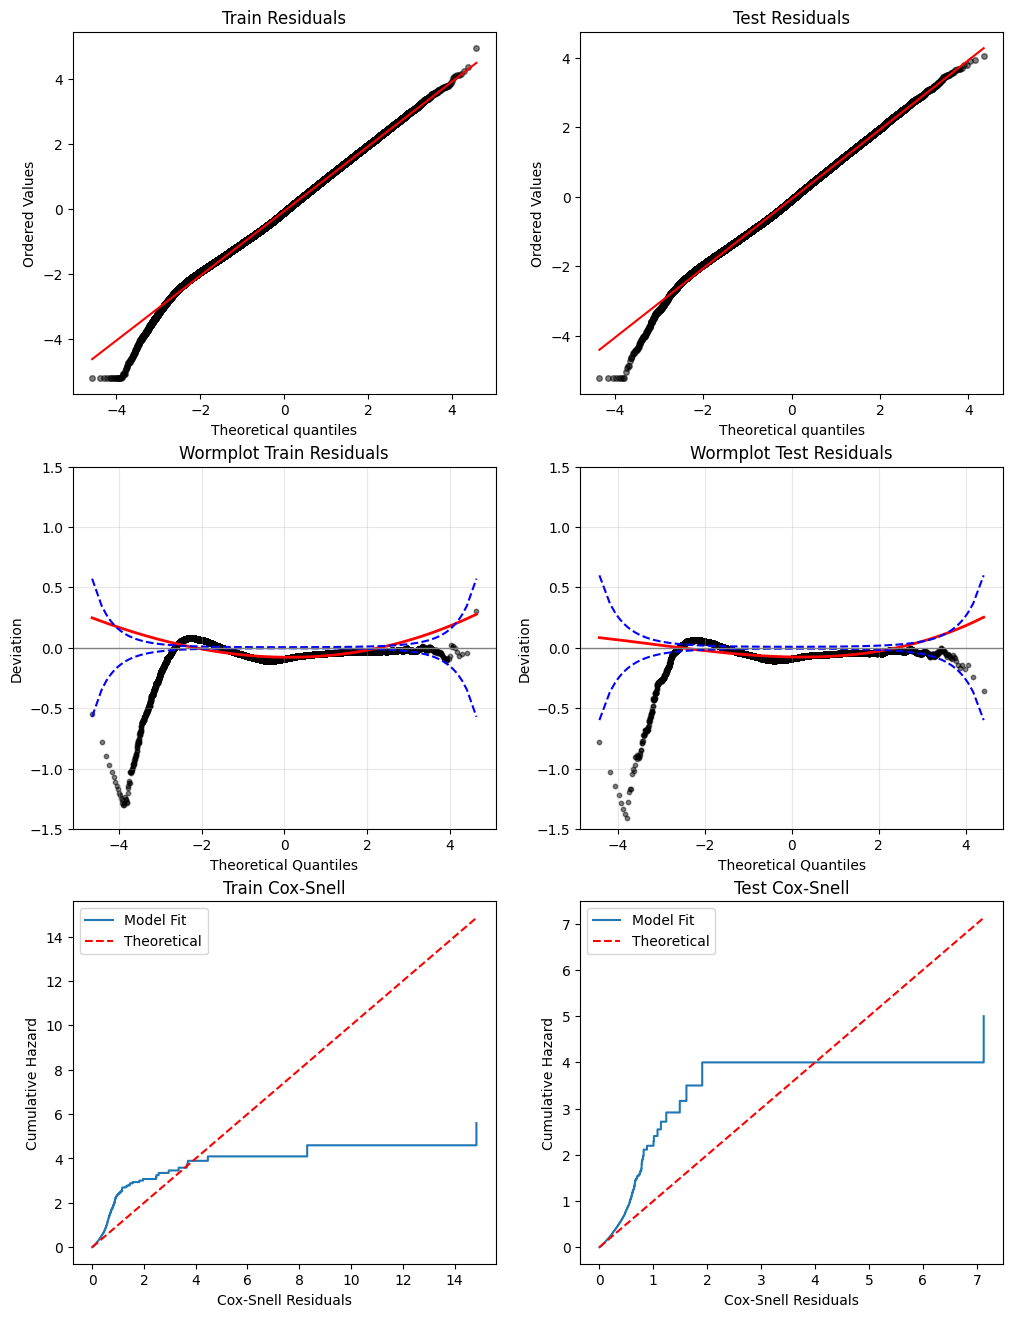

In [25]:
quant_residuals_train_full = utils.compute_randomized_residuals_censoring(S_train_full, delta_train)
quant_residuals_test_full = utils.compute_randomized_residuals_censoring(S_test_full, delta_test)
cs_residuals_train_full = H_train_full
cs_residuals_test_full = H_test_full

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_full, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_full, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_full, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_full, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

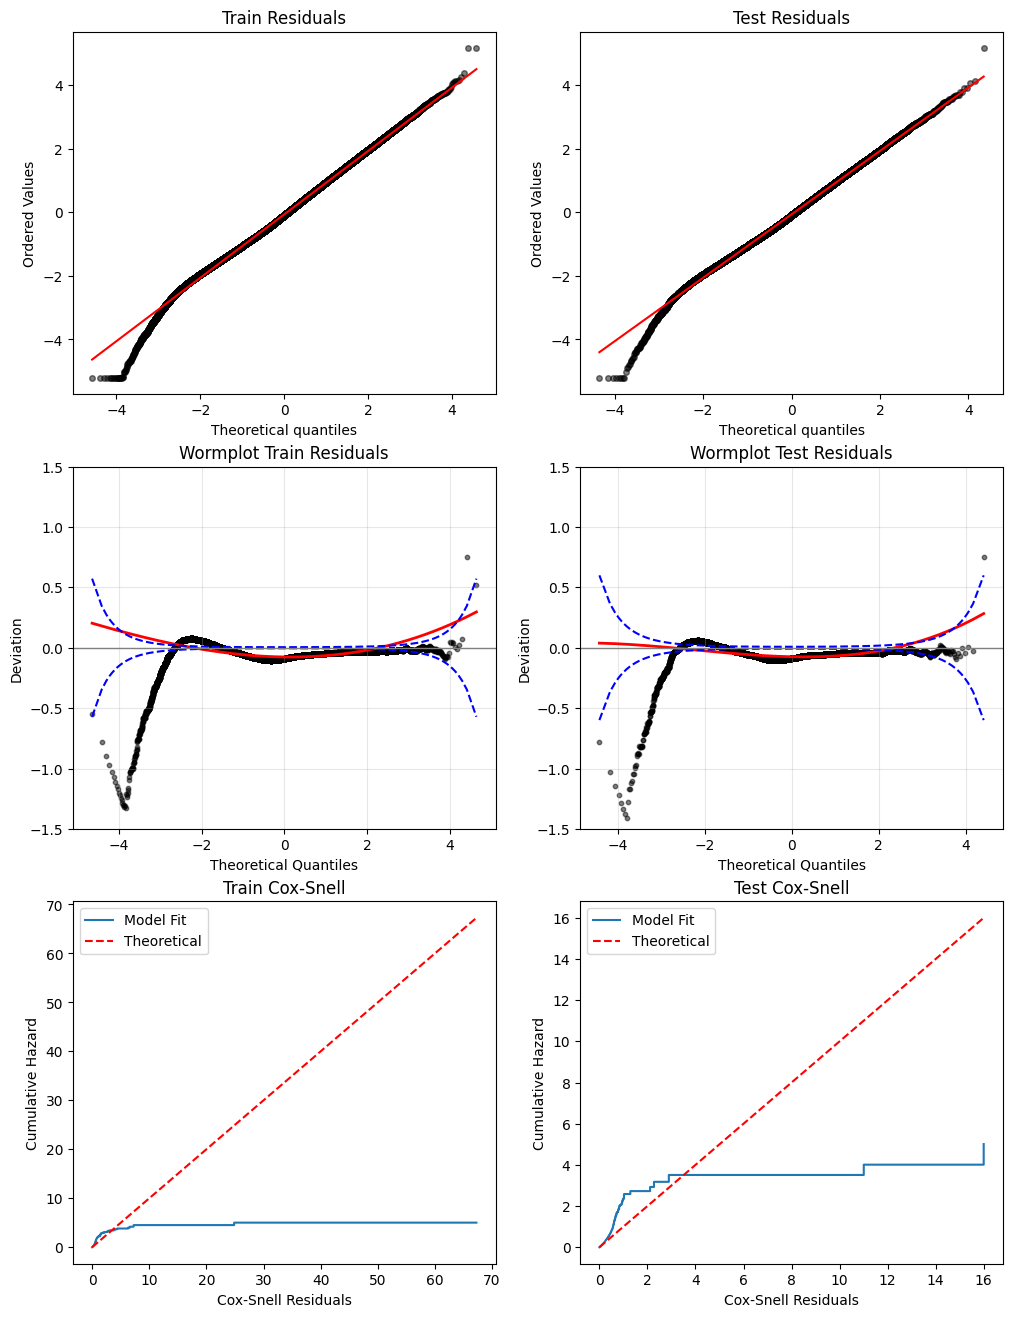

In [26]:
quant_residuals_train_linear = utils.compute_randomized_residuals_censoring(S_train_linear, delta_train)
quant_residuals_test_linear = utils.compute_randomized_residuals_censoring(S_test_linear, delta_test)
cs_residuals_train_linear = H_train_linear
cs_residuals_test_linear = H_test_linear

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_linear, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_linear, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_linear, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_linear, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_linear, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_linear, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

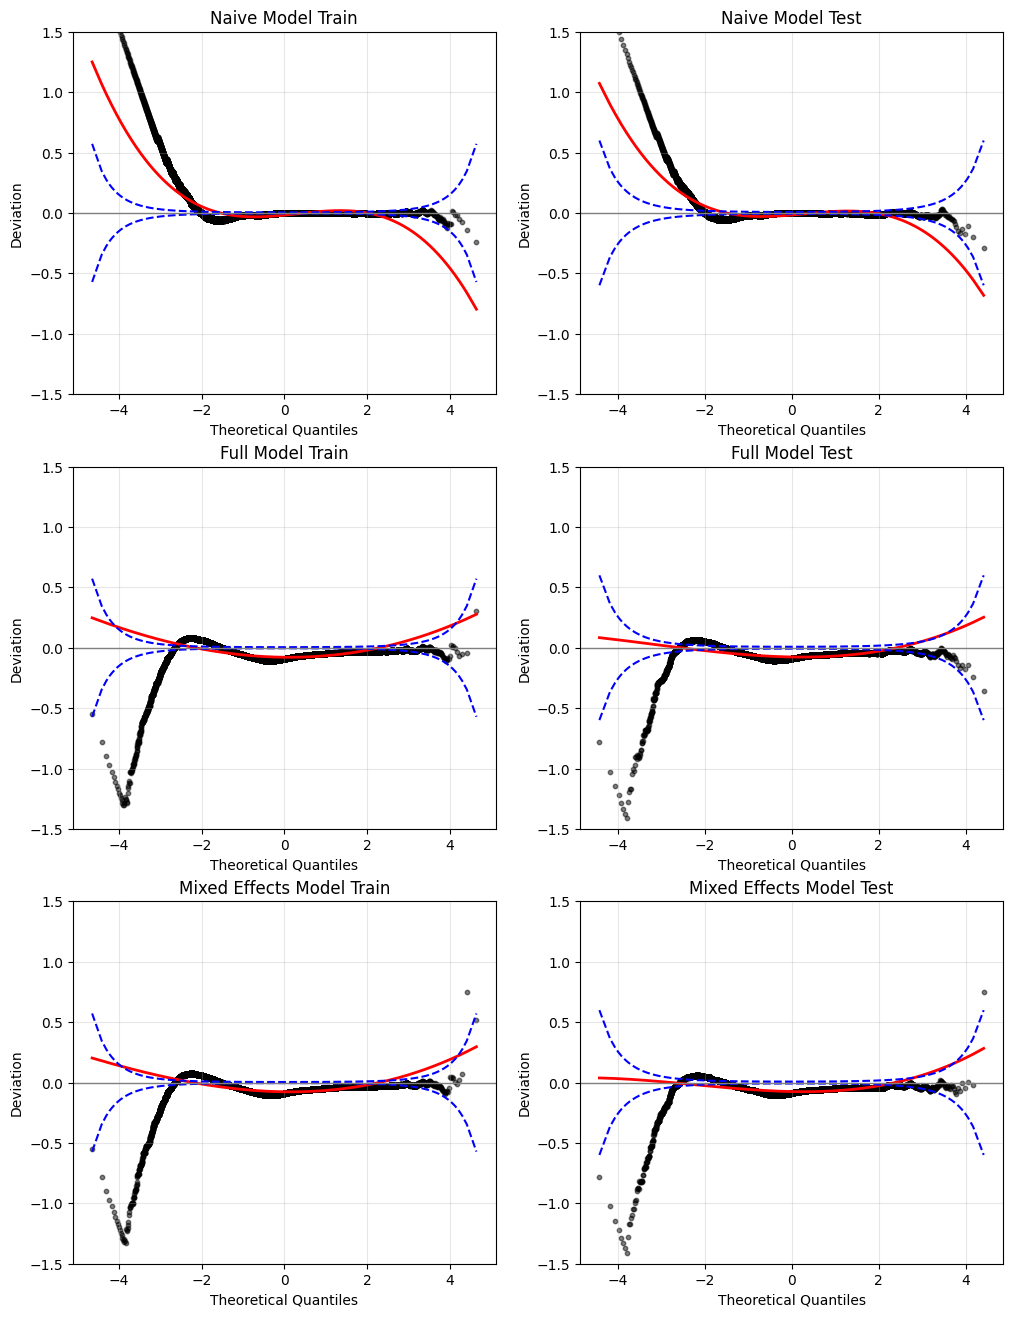

In [27]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_worm(quant_residuals_train, ax = ax[0,0], title = "Naive Model Train")
utils.plot_worm(quant_residuals_test, ax = ax[0,1], title = "Naive Model Test")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Full Model Train")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Full Model Test")
utils.plot_worm(quant_residuals_train_linear, ax = ax[2,0], title = "Mixed Effects Model Train")
utils.plot_worm(quant_residuals_test_linear, ax = ax[2,1], title = "Mixed Effects Model Test")